In [2]:
class Node():
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right
    

### 100. Same Tree

##### Given the roots of two binary trees p and q, write a function to check if they are the same or not.

##### Two binary trees are considered the same if they are structurally identical, and the nodes have the same value.

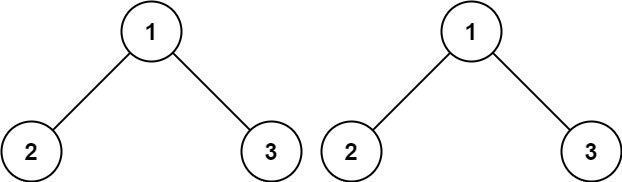

In [3]:
root = Node(1)
two = Node(2)
three = Node(3)

root.left = two
root.right = three

In [ ]:
def isSameTree(p, q):
    if p is None and q is None:
        return True
    if p is None or q is None:
        return False
    if p.value != q.value:
        return False
    
    left = isSameTree(p.left, q.left)
    right = isSameTree(p.right, q.right)
    return left and right

In [5]:
isSameTree(root, root)

True

In [8]:
from collections import deque

def isSameTree(p, q):
    def same(p, q):
        if p is None and q is None:
            return True
        if p is None or q is None:
            return False
        if p.value != q.value:
            return False
    
    queue = deque([(p, q)])
    while queue:
        p, q = queue.popleft()
        if same(p, q):
            queue.append((p.left, q.left))
            queue.append((p.right, q.right))
    
    return True

isSameTree(root, root)
    

True

#### 872. Leaf-Similar Trees

##### Consider all the leaves of a binary tree, from left to right order, the values of those leaves form a leaf value sequence.

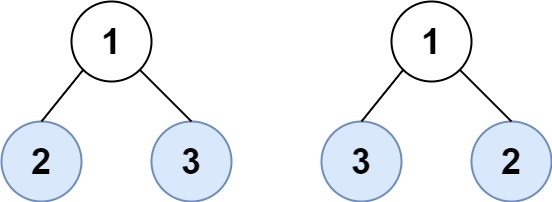

In [ ]:
from collections import deque

def leafSimilar(p, q):
    def getLeaves(root):
        leaves = []
        queue = deque([root])
        while queue:
            node = queue.popleft()
            if node.left is None and node.right is None:
                leaves.append(node.value)
            else:
                if node.left:
                    queue.append(node.left)
                if node.right:
                    queue.append(node.right)
        return leaves
    
    return getLeaves(p) == getLeaves(q)
        
    

In [18]:
leafSimilar(root, root)

True

#### 226. Invert Binary Tree
##### Given the root of a binary tree, invert the tree, and return its root.

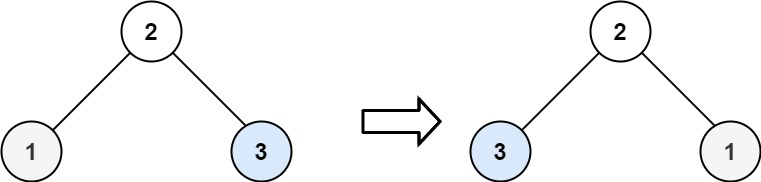

In [66]:
from collections import deque

def invertBT(root):    
    if root is None:
        return None
    
    queue = deque([root])
    while queue:
        node = queue.popleft()
        if node.left and node.right:
            node.left, node.right = node.right, node.left
        
        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)     
    
    return root

In [78]:
root = Node(2)
one = Node(1)
three = Node(3)

root.left = one
root.right = three

In [68]:
invertBT(root)

#### 101. Symmetric Tree
##### Given the root of a binary tree, check whether it is a mirror of itself (i.e., symmetric around its center).

In [ ]:
def isSymmetric(root):
    stack = [root, root]
    while stack:
        L = stack.pop()
        R = stack.pop()
        
        if L is None and R is None:
            continue
        if L is None or R is None:
            return False
        if L.value != R.value:
            return False
        stack.append(L.left)
        stack.append(R.right)
        stack.append(L.right)
        stack.append(R.left)
    return True
        


In [ ]:
from collections import deque

def isSymmetric(root):
    queue = deque()
    queue.append((root, root))
    
    while queue:
        L, R = queue.popleft()
        
        if L is None and R is None:
            continue
        if L is None or R is None:
            return False
        if L.value != R.value:
            return False
        queue.append((R.left, L.right))
        queue.append((R.right, L.left))
    return True

In [99]:
root = Node(1)

root.left = Node(2)
root.right = Node(2)

root.left.left = Node(3)
root.left.right = Node(4)

root.right.left = Node(4)
root.right.right = Node(3)

In [100]:
isSymmetric(root)

True

In [102]:
root = Node(5)
four = Node(4)
eight = Node(8)
eleven = Node(11)
thirteen = Node(13)
four_ = Node(4)
seven = Node(7)
two = Node(2)
five = Node(5)
one = Node(1)

# left subtree
root.left = four
four.left = eleven
eleven.left = seven 
eleven.right = two

# right subtree
root.right = eight
eight.left = thirteen
eight.right = four_
four_.left = five
four_.right = one

#### 113. Path Sum II

##### Given the root of a binary tree and an integer targetSum, return all root-to-leaf paths where the sum of the node values in the path equals targetSum. 
##### Each path should be returned as a list of the node values, not node references.

##### A root-to-leaf path is a path starting from the root and ending at any leaf node. A leaf is a node with no children.

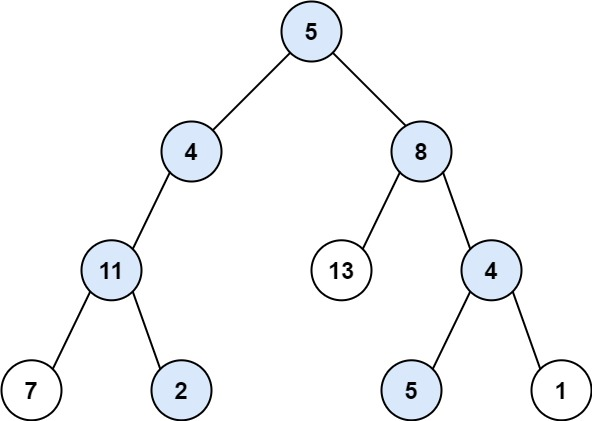

In [110]:
def preorder(root):
    if not root: return []
    res, stack = [], [root]
    while stack:
        node = stack.pop()
        res.append(node.value)            # visit
        if node.right: stack.append(node.right)
        if node.left:  stack.append(node.left)
    return res       

In [142]:
def pathSum(root, targetSum):
    paths = []
    if not root:
        return []
    
    # current node, current sum, current path
    stack = [(root, root.value, [root.value])]
    while stack:
        node, curr_sum, curr_path = stack.pop()
        
        if curr_sum == targetSum:
            if node.left is None and node.right is None:
                paths.append(curr_path)
            
        if node.right:
            right_value = node.right.value
            stack.append((node.right, curr_sum + right_value, curr_path + [right_value]))
        if node.left:
            left_value = node.left.value
            stack.append((node.left, curr_sum + left_value, curr_path + [left_value]))
            
    return paths

In [143]:
targetSum = 22
pathSum(root, targetSum)

[[5, 4, 11, 2], [5, 8, 4, 5]]

#### 1325. Delete Leaves With a Given Value

##### Given a binary tree root and an integer target, delete all the leaf nodes with value target.

##### Note that once you delete a leaf node with value target, if its parent node becomes a leaf node and has the value target, it should also be deleted (you need to continue doing that until you cannot).

In [177]:
root = Node(1)
two = Node(2)
three = Node(3)
_two = Node(2)
two_ = Node(2)
four = Node(4)

# left subtree
root.left = two
two.left = _two

# right subtree
root.right = three
three.left = two_
three.right = four

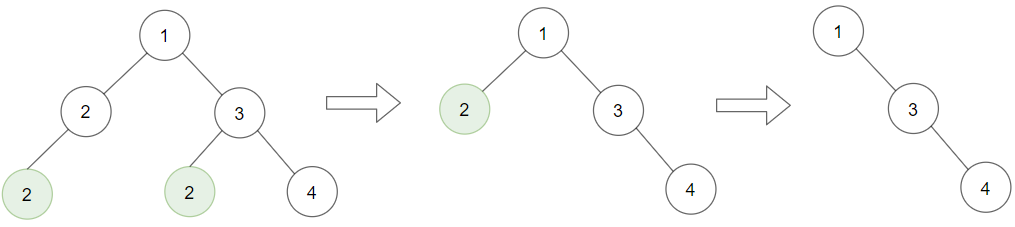

In [178]:
def postorder(root):
    if not root: return []
    s1, s2, res = [root], [], []
    while s1:
        node = s1.pop()
        s2.append(node)
        if node.left:  s1.append(node.left)
        if node.right: s1.append(node.right)
    while s2:
        res.append(s2.pop().value)        # visit
    return res


In [179]:
postorder(root)

[2, 2, 2, 4, 3, 1]

In [180]:
def removeLeafNodes(root, target):
    if not root: 
        return []
    # current node, parent node
    stack = [(root, None)]
    while stack:
        node, parent = stack.pop()
        if node.value == target:
            if node.left is None and node.right is None:
                if node is parent.left:
                    parent.left = None
                else:
                    parent.right = None
            
        if node.left:
            stack.append((node.left, node))
        if node.right:
            stack.append((node.right, node))
    return root

In [181]:
removeLeafNodes(root, 2)
postorder(root)

[2, 4, 3, 1]

#### 437. Path Sum III

##### Given the root of a binary tree and an integer targetSum, return the number of paths where the sum of the values along the path equals targetSum.

##### The path does not need to start or end at the root or a leaf, but it must go downwards (i.e., traveling only from parent nodes to child nodes).

In [254]:
root = Node(10)
five = Node(5)
three = Node(3)
two = Node(2)
eleven = Node(11)
_three = Node(3)
one = Node(1)

# left subtree
root.left = five
five.left = three
five.right = two
two.right= one
three.left = _three
three.right = Node(-2)

# right subtree
root.right = Node(-3)
root.right.right = eleven

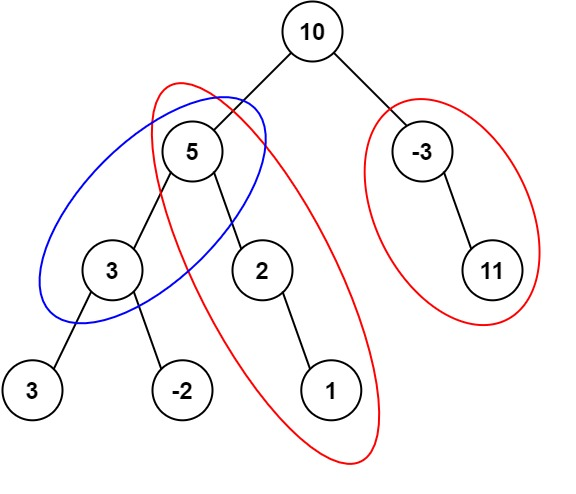

In [255]:
def postorder(root):
    if not root: return []
    s1, s2, res = [root], [], []
    while s1:
        node = s1.pop()
        s2.append(node)
        if node.left:  s1.append(node.left)
        if node.right: s1.append(node.right)
    while s2:
        res.append(s2.pop().value)        # visit
    return res


In [256]:
def pathSum(root, target):
    num_paths = 0
    if root is None:
        return []
    # node, current sum, current path, parent
    stack = [(root, 0, [], None)]
    while stack:
        node, curr_sum, curr_path, parent = stack.pop()
        
        if curr_sum == target:
            num_paths += 1
            
        if node.left:
            stack.append((node.left,
                         curr_sum + node.left.value,
                         curr_path + [node.left.value],
                         node))
        if node.right:
            stack.append((node.right,
                         curr_sum + node.right.value,
                         curr_path + [node.right.value],
                         node))
    return num_paths

In [257]:
pathSum(root, 8)

3

#### 1372. Longest ZigZag Path in a Binary Tree

##### You are given the root of a binary tree.

##### A ZigZag path for a binary tree is defined as follow:

##### Choose any node in the binary tree and a direction (right or left).
##### If the current direction is right, move to the right child of the current node; otherwise, move to the left child.
##### Change the direction from right to left or from left to right.
##### Repeat the second and third steps until you can't move in the tree.
##### Zigzag length is defined as the number of nodes visited - 1. (A single node has a length of 0).

##### Return the longest ZigZag path contained in that tree.

In [266]:
root = Node(1)

# left subtree
# root.left = Node(1)

# right subtree
root.right = Node(1)

root.right.left = Node(1)
root.right.right = Node(1)

root.right.right.left = Node(1)
root.right.right.right = Node(1)

root.right.right.left.right = Node(1)
root.right.right.left.right.right = Node(1)

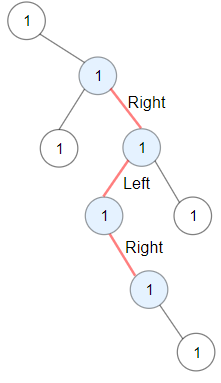

In [ ]:
def longestZigZag(root):
    longest = 0
    
    if root is None:
        return 0
    
    stack = [(root.left, 1, False), (root.right, 1, True)]
    while stack:
        node, curr_len, prev_dir = stack.pop()
        
        if not node:
            continue # skip iteration
        longest = max(longest, curr_len)
        
        # previous direction was Right
        if prev_dir == True:
            stack.append((node.left, curr_len + 1, False))
            stack.append((node.right, 1, True))
        else:
            stack.append((node.right, curr_len + 1, True))
            stack.append((node.left, 1, False))
    return longest

In [287]:
longestZigZag(root)

3

### 450. Delete Node in a BST

#### Given a root node reference of a BST and a key, delete the node with the given key in the BST. Return the root node reference (possibly updated) of the BST.

#### Basically, the deletion can be divided into two stages:

#### Search for a node to remove.
#### If the node is found, delete the node.


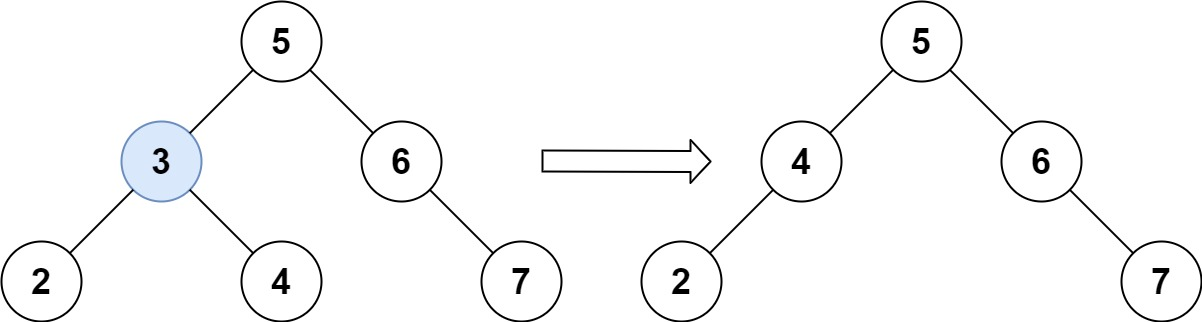

In [81]:
root = Node(5)
three = Node(3)
six = Node(6)
two = Node(2)
four = Node(4)
seven = Node(7)

root.left = three
root.right = six
three.right = four
six.right = seven

In [82]:
def deleteNode(root, target):
    stack = [(root, None)]
    target, parent = None, None
    while stack:
        node, parent = stack.pop()
            
        if not node:
            continue
        if node.value == target:
            target, parent = node, parent
            break
        stack.append((node.right, node))
        stack.append((node.left, node))
            
        if not target:
            return root
        
    if target.left and target.right:
        par, succ = target, target.right
        while succ.left:
            par, succ = succ, succ.left
        target.value = succ.value
        parent, target = par, succ
        
    child = target.left or target.right
    if not parent:
        return child
    if parent.left is target:
        parent.left = child
    else:
        parent.right = child
    return root
        
            

In [83]:
deleteNode(root, 3)

In [84]:
root.left.value

3